Accuracy: 1.00


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import pandas as pd
import numpy as np
from scipy import stats

# 1. Load Data
housing = fetch_california_housing()

# 2. Creiamo il DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["target"] = housing.target

# 3. Funzione 
def remove_outliers_zscore(data, columns, threshold=3):
    df_clean = data.copy()
    
    # Calcoliamo lo Z-score assoluto per ogni colonna selezionata
    z_scores = np.abs(stats.zscore(df_clean[columns]))

    # Teniamo solo le righe dove TUTTE le colonne hanno Z < threshold
    filtered_entries = (z_scores < threshold).all(axis=1)
    
    return df_clean[filtered_entries]


# 4. Applicazione su MedInc, AveRooms, AveOccup
df_zscore = remove_outliers_zscore(df, ['MedInc', 'AveRooms', 'AveOccup'])

print(f"Righe rimosse con Z-Score: {len(df) - len(df_zscore)}")


# 5. Ricreiamo X e y puliti
X = df_zscore[housing.feature_names].values
y = df_zscore["target"].values

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# 3. Predictions and Residuals
y_pred = model.predict(X_test)
residuals = y_test - y_pred

mse = mean_squared_error(y_test, y_pred)

print(mse)

# 4. PLOTTING
plt.figure(figsize=(12, 5))

# --- Plot 1: Regression Line (using 'Median Income' which is index 0) ---
plt.subplot(1, 2, 1)
# Plotting only the first feature (Median Income) vs Target
plt.scatter(X_test[:, 0], y_test, color='blue', alpha=0.3, label='Actual Data')
# Fit a simple line just for this plot to visualize the trend
sns.regplot(x=X_test[:, 0], y=y_test, scatter=False, color='red', label='Regression Line')
plt.title('Feature vs Price (MedInc)')
plt.xlabel('Median Income')
plt.ylabel('House Value ($100k)')
plt.legend()

# --- Plot 2: Residual Plot ---
plt.subplot(1, 2, 2)
plt.scatter(y_pred, residuals, color='purple', alpha=0.3)
plt.axhline(y=0, color='black', linestyle='--') # Zero error line
plt.title('Residual Plot (Errors)')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Actual - Predicted)')

plt.tight_layout()
plt.show()

Righe rimosse con Z-Score: 482
0.4534256767704537


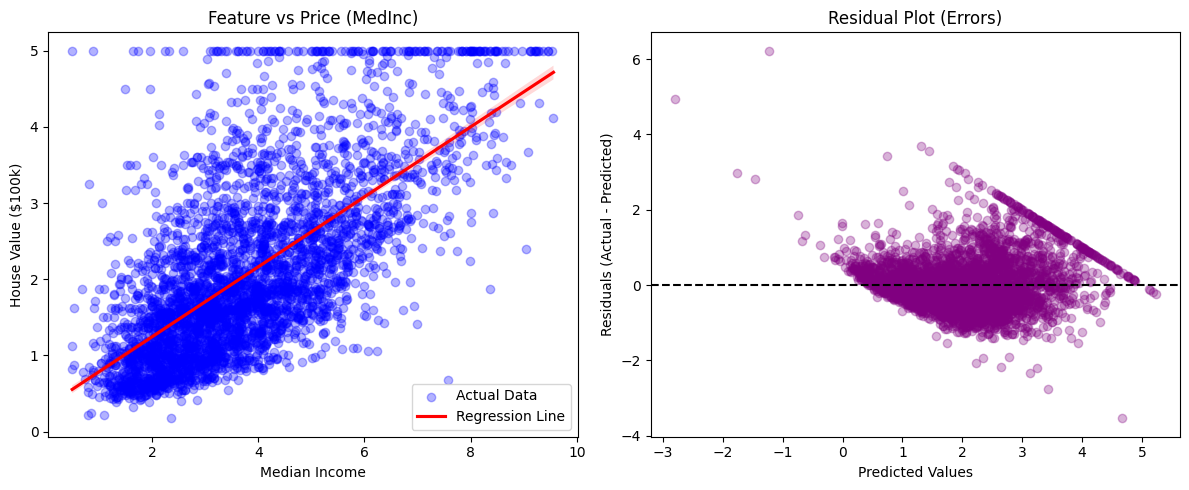

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import pandas as pd
import numpy as np
from scipy import stats

# 1. Load Data
housing = fetch_california_housing()

# 2. Creiamo il DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["target"] = housing.target

# 3. Funzione 
def remove_outliers_zscore(data, columns, threshold=3):
    df_clean = data.copy()
    
    # Calcoliamo lo Z-score assoluto per ogni colonna selezionata
    z_scores = np.abs(stats.zscore(df_clean[columns]))

    # Teniamo solo le righe dove TUTTE le colonne hanno Z < threshold
    filtered_entries = (z_scores < threshold).all(axis=1)
    
    return df_clean[filtered_entries]


# 4. Applicazione su MedInc, AveRooms, AveOccup
df_zscore = remove_outliers_zscore(df, ['MedInc', 'AveRooms', 'AveOccup'])

print(f"Righe rimosse con Z-Score: {len(df) - len(df_zscore)}")


# 5. Ricreiamo X e y puliti
X = df_zscore[housing.feature_names].values
y = df_zscore["target"].values

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# 3. Predictions and Residuals
y_pred = model.predict(X_test)
residuals = y_test - y_pred

mse = mean_squared_error(y_test, y_pred)

print(mse)

# 4. PLOTTING
plt.figure(figsize=(12, 5))

# --- Plot 1: Regression Line (using 'Median Income' which is index 0) ---
plt.subplot(1, 2, 1)
# Plotting only the first feature (Median Income) vs Target
plt.scatter(X_test[:, 0], y_test, color='blue', alpha=0.3, label='Actual Data')
# Fit a simple line just for this plot to visualize the trend
sns.regplot(x=X_test[:, 0], y=y_test, scatter=False, color='red', label='Regression Line')
plt.title('Feature vs Price (MedInc)')
plt.xlabel('Median Income')
plt.ylabel('House Value ($100k)')
plt.legend()

# --- Plot 2: Residual Plot ---
plt.subplot(1, 2, 2)
plt.scatter(y_pred, residuals, color='purple', alpha=0.3)
plt.axhline(y=0, color='black', linestyle='--') # Zero error line
plt.title('Residual Plot (Errors)')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Actual - Predicted)')

plt.tight_layout()
plt.show()